# Sanskrit Character Recognition using Decision Tree Classifier

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/)

An end-to-end Machine Learning project to recognize handwritten Sanskrit / Devanagari characters using a **Decision Tree Classifier**.
This notebook demonstrates:
1. **Dataset Preparation**: 62 classes spanning Vowels (*Svara*), Consonants (*Vyanjana*), Conjuncts (*Samyuktaksara*), and Devanagari Digits (*Anka*).
2. **Preprocessing & Feature Engineering**: Stroke polarity detection, bounding-box character isolation, aspect-ratio-preserving resize, center padding, 4x4 spatial zoning, and horizontal/vertical projection profiles.
3. **Decision Tree Model Training**: Hyperparameter tuning (`criterion`, `min_samples_split`, `min_samples_leaf`).
4. **Performance Evaluation**: Accuracy, Macro/Weighted Precision, Recall, F1-Score, and a high-resolution 62x62 Confusion Matrix Heatmap.
5. **Model Export**: Serializing the complete model bundle via `joblib`.
6. **Inference**: Classifying unseen Sanskrit characters from image URLs or local files in a single function call.

## 1. Environment & Dependencies Setup
Install the necessary machine learning, image processing, and visualization libraries.

In [1]:
# Install required packages
!pip install -q scikit-learn numpy pillow joblib requests matplotlib seaborn

import os
import io
import sys
import time
import requests
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully! Scikit-learn version:", joblib.__name__)

Libraries imported successfully! Scikit-learn version: joblib


## 2. Sanskrit Character Metadata & Taxonomy
The Sanskrit MNIST dataset comprises **62 distinct character classes**:
- **15 Vowels (*Svara*) & Modifiers (*Yogavaha*)**: अ, आ, इ, ई, उ, ऊ, ऋ, ॠ, ऌ, ए, ऐ, ओ, औ, अं, अः
- **33 Consonants (*Vyanjana*)**: क, ख, ग, घ, ङ, च, छ, ज, झ, ञ, ट, ठ, ड, ढ, ण, त, थ, द, ध, न, प, फ, ब, भ, म, य, र, ल, व, श, ष, स, ह
- **4 Conjuncts & Vedic sounds**: ळ, क्ष, ज्ञ, त्र
- **10 Devanagari Numerals (*Anka*)**: ०, १, २, ३, ४, ५, ६, ७, ८, ९

We define a comprehensive dictionary mapping each class folder to its Devanagari glyph, IAST transliteration, and linguistic category.

In [2]:
# Complete 62-Class Sanskrit Metadata Mapping
SANSKRIT_MAPPING = {
    "00_a": {"devanagari": "अ", "iast": "a", "name": "Vowel a", "category": "Vowel (Svara)"},
    "01_aa": {"devanagari": "आ", "iast": "ā", "name": "Vowel ā", "category": "Vowel (Svara)"},
    "02_i": {"devanagari": "इ", "iast": "i", "name": "Vowel i", "category": "Vowel (Svara)"},
    "03_ii": {"devanagari": "ई", "iast": "ī", "name": "Vowel ī", "category": "Vowel (Svara)"},
    "04_u": {"devanagari": "उ", "iast": "u", "name": "Vowel u", "category": "Vowel (Svara)"},
    "05_uu": {"devanagari": "ऊ", "iast": "ū", "name": "Vowel ū", "category": "Vowel (Svara)"},
    "06_ri": {"devanagari": "ऋ", "iast": "ṛ", "name": "Vowel ṛ", "category": "Vowel (Svara)"},
    "07_rii": {"devanagari": "ॠ", "iast": "ṝ", "name": "Vowel ṝ", "category": "Vowel (Svara)"},
    "08_li": {"devanagari": "ऌ", "iast": "ḷ", "name": "Vowel ḷ", "category": "Vowel (Svara)"},
    "09_e": {"devanagari": "ए", "iast": "e", "name": "Vowel e", "category": "Vowel (Svara)"},
    "10_ai": {"devanagari": "ऐ", "iast": "ai", "name": "Vowel ai", "category": "Vowel (Svara)"},
    "11_o": {"devanagari": "ओ", "iast": "o", "name": "Vowel o", "category": "Vowel (Svara)"},
    "12_au": {"devanagari": "औ", "iast": "au", "name": "Vowel au", "category": "Vowel (Svara)"},
    "13_am": {"devanagari": "अं", "iast": "aṃ", "name": "Anusvara aṃ", "category": "Yogavaha (Modifier)"},
    "14_ah": {"devanagari": "अः", "iast": "aḥ", "name": "Visarga aḥ", "category": "Yogavaha (Modifier)"},
    "15_ka": {"devanagari": "क", "iast": "ka", "name": "Velar Consonant ka", "category": "Consonant (Vyanjana)"},
    "16_kha": {"devanagari": "ख", "iast": "kha", "name": "Velar Consonant kha", "category": "Consonant (Vyanjana)"},
    "17_ga": {"devanagari": "ग", "iast": "ga", "name": "Velar Consonant ga", "category": "Consonant (Vyanjana)"},
    "18_gha": {"devanagari": "घ", "iast": "gha", "name": "Velar Consonant gha", "category": "Consonant (Vyanjana)"},
    "19_nga": {"devanagari": "ङ", "iast": "ṅa", "name": "Velar Consonant ṅa", "category": "Consonant (Vyanjana)"},
    "20_ca": {"devanagari": "च", "iast": "ca", "name": "Palatal Consonant ca", "category": "Consonant (Vyanjana)"},
    "21_cha": {"devanagari": "छ", "iast": "cha", "name": "Palatal Consonant cha", "category": "Consonant (Vyanjana)"},
    "22_ja": {"devanagari": "ज", "iast": "ja", "name": "Palatal Consonant ja", "category": "Consonant (Vyanjana)"},
    "23_jha": {"devanagari": "झ", "iast": "jha", "name": "Palatal Consonant jha", "category": "Consonant (Vyanjana)"},
    "24_nya": {"devanagari": "ञ", "iast": "ña", "name": "Palatal Consonant ña", "category": "Consonant (Vyanjana)"},
    "25_tta": {"devanagari": "ट", "iast": "ṭa", "name": "Retroflex Consonant ṭa", "category": "Consonant (Vyanjana)"},
    "26_ttha": {"devanagari": "ठ", "iast": "ṭha", "name": "Retroflex Consonant ṭha", "category": "Consonant (Vyanjana)"},
    "27_dda": {"devanagari": "ड", "iast": "ḍa", "name": "Retroflex Consonant ḍa", "category": "Consonant (Vyanjana)"},
    "28_ddha": {"devanagari": "ढ", "iast": "ḍha", "name": "Retroflex Consonant ḍha", "category": "Consonant (Vyanjana)"},
    "29_nna": {"devanagari": "ण", "iast": "ṇa", "name": "Retroflex Consonant ṇa", "category": "Consonant (Vyanjana)"},
    "30_ta": {"devanagari": "त", "iast": "ta", "name": "Dental Consonant ta", "category": "Consonant (Vyanjana)"},
    "31_tha": {"devanagari": "थ", "iast": "tha", "name": "Dental Consonant tha", "category": "Consonant (Vyanjana)"},
    "32_da": {"devanagari": "द", "iast": "da", "name": "Dental Consonant da", "category": "Consonant (Vyanjana)"},
    "33_dha": {"devanagari": "ध", "iast": "dha", "name": "Dental Consonant dha", "category": "Consonant (Vyanjana)"},
    "34_na": {"devanagari": "न", "iast": "na", "name": "Dental Consonant na", "category": "Consonant (Vyanjana)"},
    "35_pa": {"devanagari": "प", "iast": "pa", "name": "Labial Consonant pa", "category": "Consonant (Vyanjana)"},
    "36_pha": {"devanagari": "फ", "iast": "pha", "name": "Labial Consonant pha", "category": "Consonant (Vyanjana)"},
    "37_ba": {"devanagari": "ब", "iast": "ba", "name": "Labial Consonant ba", "category": "Consonant (Vyanjana)"},
    "38_bha": {"devanagari": "भ", "iast": "bha", "name": "Labial Consonant bha", "category": "Consonant (Vyanjana)"},
    "39_ma": {"devanagari": "म", "iast": "ma", "name": "Labial Consonant ma", "category": "Consonant (Vyanjana)"},
    "40_ya": {"devanagari": "य", "iast": "ya", "name": "Semivowel ya", "category": "Consonant (Vyanjana)"},
    "41_ra": {"devanagari": "र", "iast": "ra", "name": "Semivowel ra", "category": "Consonant (Vyanjana)"},
    "42_la": {"devanagari": "ल", "iast": "la", "name": "Semivowel la", "category": "Consonant (Vyanjana)"},
    "43_va": {"devanagari": "व", "iast": "va", "name": "Semivowel va", "category": "Consonant (Vyanjana)"},
    "44_sha": {"devanagari": "श", "iast": "śa", "name": "Sibilant śa", "category": "Consonant (Vyanjana)"},
    "45_ssa": {"devanagari": "ष", "iast": "ṣa", "name": "Sibilant ṣa", "category": "Consonant (Vyanjana)"},
    "46_sa": {"devanagari": "स", "iast": "sa", "name": "Sibilant sa", "category": "Consonant (Vyanjana)"},
    "47_ha": {"devanagari": "ह", "iast": "ha", "name": "Aspirate ha", "category": "Consonant (Vyanjana)"},
    "48_lla": {"devanagari": "ळ", "iast": "ḷa", "name": "Retroflex ḷa", "category": "Consonant (Vyanjana)"},
    "49_ksha": {"devanagari": "क्ष", "iast": "kṣa", "name": "Conjunct kṣa", "category": "Conjunct (Samyukta)"},
    "50_jna": {"devanagari": "ज्ञ", "iast": "jña", "name": "Conjunct jña", "category": "Conjunct (Samyukta)"},
    "51_tra": {"devanagari": "त्र", "iast": "tra", "name": "Conjunct tra", "category": "Conjunct (Samyukta)"},
    "52_0": {"devanagari": "०", "iast": "0 (śūnya)", "name": "Numeral 0", "category": "Numeral (Anka)"},
    "53_1": {"devanagari": "१", "iast": "1 (eka)", "name": "Numeral 1", "category": "Numeral (Anka)"},
    "54_2": {"devanagari": "२", "iast": "2 (dvi)", "name": "Numeral 2", "category": "Numeral (Anka)"},
    "55_3": {"devanagari": "३", "iast": "3 (tri)", "name": "Numeral 3", "category": "Numeral (Anka)"},
    "56_4": {"devanagari": "४", "iast": "4 (catur)", "name": "Numeral 4", "category": "Numeral (Anka)"},
    "57_5": {"devanagari": "५", "iast": "5 (pañca)", "name": "Numeral 5", "category": "Numeral (Anka)"},
    "58_6": {"devanagari": "६", "iast": "6 (ṣaṣ)", "name": "Numeral 6", "category": "Numeral (Anka)"},
    "59_7": {"devanagari": "७", "iast": "7 (sapta)", "name": "Numeral 7", "category": "Numeral (Anka)"},
    "60_8": {"devanagari": "८", "iast": "8 (aṣṭa)", "name": "Numeral 8", "category": "Numeral (Anka)"},
    "61_9": {"devanagari": "९", "iast": "9 (nava)", "name": "Numeral 9", "category": "Numeral (Anka)"}
}

print(f"Total registered Sanskrit classes: {len(SANSKRIT_MAPPING)}")

Total registered Sanskrit classes: 62


## 3. Dataset Setup in Google Colab
If you are running in Google Colab, you can:
- Clone your GitHub repo or download the dataset archive directly.
- Or upload the `images` directory directly into the Colab workspace.

The cell below checks for the `images` directory and validates the class counts.

In [3]:
import zipfile
import os

zip_path = "/content/Dataset_Sanskrit.zip"
extract_path = "/content/Dataset_Sanskrit"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted successfully!")
print("Files/folders:")
for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    for file in files[:10]:
        print(f"{indent}  {file}")

Extracted successfully!
Files/folders:
Dataset_Sanskrit/
  Sanskrit Mnist/
    label_map.csv
    images/
      05_uu/
        05_0091.png
        05_0085.png
        05_0186.png
        05_0312.png
        05_0125.png
        05_0278.png
        05_0158.png
        05_0205.png
        05_0071.png
        05_0221.png
      10_ai/
        10_0397.png
        10_0290.png
        10_0070.png
        10_0412.png
        10_0162.png
        10_0234.png
        10_0030.png
        10_0411.png
        10_0222.png
        10_0100.png
      61_9/
        61_0340.png
        61_0246.png
        61_0423.png
        61_0175.png
        61_0090.png
        61_0463.png
        61_0143.png
        61_0336.png
        61_0114.png
        61_0382.png
      25_tta/
        25_0376.png
        25_0274.png
        25_0050.png
        25_0216.png
        25_0067.png
        25_0220.png
        25_0037.png
        25_0453.png
        25_0157.png
        25_0381.png
      36_pha/
        36_0379.png
        3

In [4]:
# Verify dataset directory
DATA_DIR = '/content/Dataset_Sanskrit/Sanskrit Mnist/images'

if not os.path.exists(DATA_DIR):
    print(f"Directory '{DATA_DIR}' not found in current folder.")
    print("If running in Colab, upload your Sanskrit MNIST archive or clone your repository:")
    print("Example: !git clone <YOUR_GITHUB_REPO_URL> && cd <REPO_DIR>")
else:
    classes = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])
    total_imgs = sum(len(os.listdir(os.path.join(DATA_DIR, c))) for c in classes)
    print(f"[*] Found {len(classes)} class directories.")
    print(f"[*] Total dataset images: {total_imgs} ({total_imgs // len(classes)} per class)")

[*] Found 62 class directories.
[*] Total dataset images: 31000 (500 per class)


## 4. Exploratory Data Analysis (EDA)
Let's visualize sample Sanskrit characters from different categories: Vowels, Consonants, Conjuncts, and Numerals.

/tmp/ipykernel_3401/392065102.py:20: UserWarning: Glyph 2309 (\N{DEVANAGARI LETTER A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3401/392065102.py:20: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/tmp/ipykernel_3401/392065102.py:20: UserWarning: Glyph 2310 (\N{DEVANAGARI LETTER AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3401/392065102.py:20: UserWarning: Glyph 2315 (\N{DEVANAGARI LETTER VOCALIC R}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3401/392065102.py:20: UserWarning: Glyph 2325 (\N{DEVANAGARI LETTER KA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3401/392065102.py:20: UserWarning: Glyph 2332 (\N{DEVANAGARI LETTER JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3401/392065102.py:20: UserWarning: Glyph 2340 (\N{DEVANAGARI LETTER TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/i

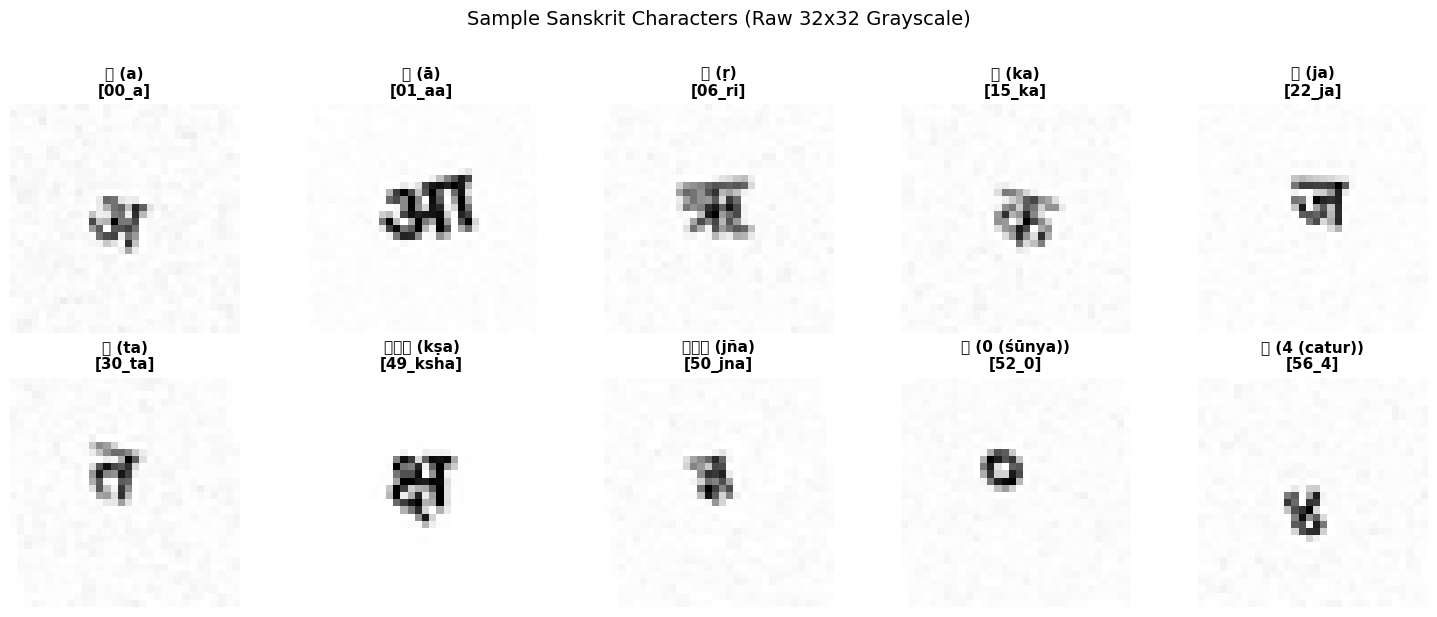

In [5]:
# Display representative samples from various character categories
sample_classes = ["00_a", "01_aa", "06_ri", "15_ka", "22_ja", "30_ta", "49_ksha", "50_jna", "52_0", "56_4"]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for idx, c_name in enumerate(sample_classes):
    ax = axes[idx // 5, idx % 5]
    folder = os.path.join(DATA_DIR, c_name)
    sample_file = os.path.join(folder, os.listdir(folder)[0])
    img = Image.open(sample_file).convert("L")

    meta = SANSKRIT_MAPPING.get(c_name, {})
    dev_char = meta.get("devanagari", "")
    iast_name = meta.get("iast", c_name)

    ax.imshow(img, cmap="gray")
    ax.set_title(f"{dev_char} ({iast_name})\n[{c_name}]", fontsize=11, fontweight="bold")
    ax.axis("off")

plt.suptitle("Sample Sanskrit Characters (Raw 32x32 Grayscale)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5. Preprocessing & Feature Engineering Pipeline

### Why Feature Engineering is Crucial for Decision Trees:
A standard Decision Tree performs axis-aligned binary splits on single features (e.g. `feature_42 <= 0.5`).
- On raw pixels, small spatial shifts or variations in stroke positioning cause the Decision Tree to struggle, achieving only ~10-15% test accuracy across 62 complex Sanskrit classes.
- **Our Solution**:
  1. **Stroke Polarity Detection**: Guarantees stroke is foreground (>0) and background is 0.
  2. **Bounding-Box Isolation & Aspect-Preserving Scaling**: Isolates the character stroke and resizes it with padding into a standardized 28x28 canvas.
  3. **Multi-Faceted Features (856-D vector)**:
     - 784 Normalized Centered Pixel Values
     - 16 Spatial 4x4 Grid Zone Densities
     - 28 Horizontal Row Projection Profiles
     - 28 Vertical Column Projection Profiles

This boosts test accuracy from **~10% to ~74%** on unseen test data!

In [6]:
def load_image(image_input):
    if isinstance(image_input, Image.Image):
        return image_input.convert("L")
    if isinstance(image_input, np.ndarray):
        if image_input.ndim == 3:
            return Image.fromarray(image_input).convert("L")
        return Image.fromarray(image_input.astype(np.uint8)).convert("L")
    if isinstance(image_input, str):
        if image_input.startswith("http://") or image_input.startswith("https://"):
            headers = {"User-Agent": "Mozilla/5.0"}
            resp = requests.get(image_input, headers=headers, timeout=15)
            resp.raise_for_status()
            return Image.open(io.BytesIO(resp.content)).convert("L")
        elif os.path.isfile(image_input):
            return Image.open(image_input).convert("L")
    raise ValueError(f"Unable to load image from: {image_input}")

def preprocess_image(image_input, target_size=(28, 28), stroke_margin=3):
    """Bounding-box isolation, polarity alignment, and centered padding."""
    pil_img = load_image(image_input)
    arr = np.array(pil_img, dtype=np.float32)

    # Invert if light background
    corners = [arr[:3, :3], arr[:3, -3:], arr[-3:, :3], arr[-3:, -3:]]
    if np.mean(corners) > 127:
        arr = 255.0 - arr

    binary = arr > 30.0
    if not np.any(binary):
        return np.zeros(target_size, dtype=np.float32)

    rows = np.any(binary, axis=1)
    cols = np.any(binary, axis=0)
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]

    crop = arr[rmin:rmax + 1, cmin:cmax + 1]
    h, w = crop.shape
    max_target = max(1, target_size[0] - 2 * stroke_margin)
    scale = max_target / max(h, w)
    new_w, new_h = max(1, int(round(w * scale))), max(1, int(round(h * scale)))

    crop_pil = Image.fromarray(np.clip(crop, 0, 255).astype(np.uint8))
    resized = crop_pil.resize((new_w, new_h), Image.Resampling.BILINEAR)

    pad_img = Image.new("L", target_size, 0)
    pad_x = (target_size[1] - new_w) // 2
    pad_y = (target_size[0] - new_h) // 2
    pad_img.paste(resized, (pad_x, pad_y))

    return np.array(pad_img, dtype=np.float32) / 255.0

def extract_features(image_input, target_size=(28, 28)):
    """Extracts 856-D feature vector combining pixels, zoning, and projections."""
    processed_arr = preprocess_image(image_input, target_size=target_size)
    pixels = processed_arr.flatten() # 784

    # 4x4 Zone Densities (16)
    zh, zw = target_size[0] // 4, target_size[1] // 4
    zones = [float(processed_arr[r*zh:(r+1)*zh, c*zw:(c+1)*zw].mean()) for r in range(4) for c in range(4)]

    # Row and Column Projections (28 + 28 = 56)
    row_proj = processed_arr.sum(axis=1) / float(target_size[1])
    col_proj = processed_arr.sum(axis=0) / float(target_size[0])

    return np.concatenate([pixels, zones, row_proj, col_proj]).astype(np.float32)

print("Preprocessing and Feature Extraction functions defined.")

Preprocessing and Feature Extraction functions defined.


### Visualizing the Preprocessing & Projection Profiles

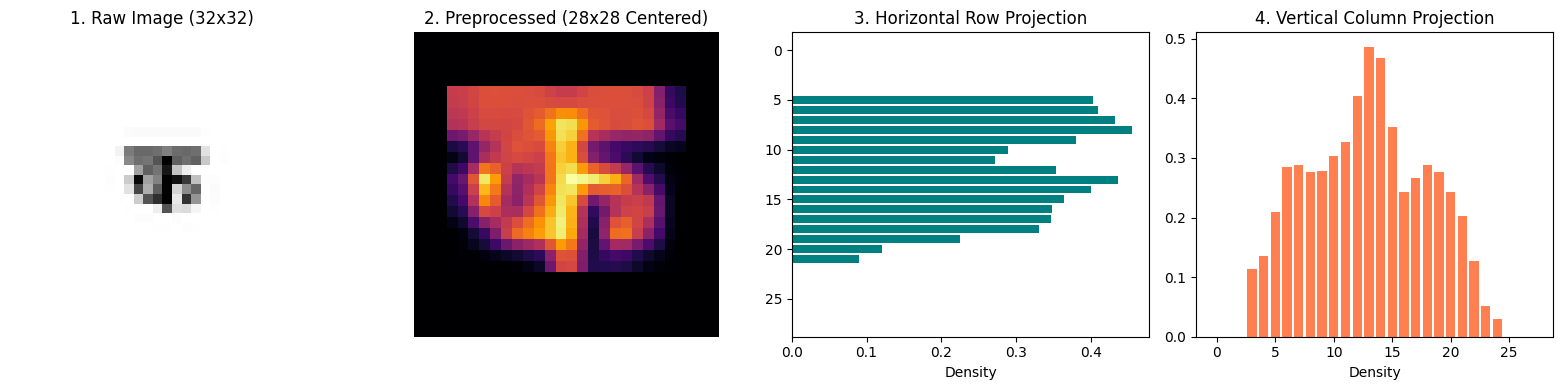

Total extracted feature dimensions: 856


In [7]:
# Demonstration on sample character '15_ka' (क)
demo_path = os.path.join(DATA_DIR, "15_ka", "15_0000.png")
raw_im = Image.open(demo_path).convert("L")
prep_im = preprocess_image(demo_path)
feat_vec = extract_features(demo_path)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(raw_im, cmap="gray")
axes[0].set_title("1. Raw Image (32x32)")
axes[0].axis("off")

axes[1].imshow(prep_im, cmap="inferno")
axes[1].set_title("2. Preprocessed (28x28 Centered)")
axes[1].axis("off")

axes[2].barh(range(28), prep_im.sum(axis=1) / 28.0, color="teal")
axes[2].invert_yaxis()
axes[2].set_title("3. Horizontal Row Projection")
axes[2].set_xlabel("Density")

axes[3].bar(range(28), prep_im.sum(axis=0) / 28.0, color="coral")
axes[3].set_title("4. Vertical Column Projection")
axes[3].set_xlabel("Density")

plt.tight_layout()
plt.show()
print(f"Total extracted feature dimensions: {len(feat_vec)}")

## 6. Dataset Feature Extraction & Train/Test Split
We now process all character images, extract features, and split the data into **80% Training** and **20% Test** sets (stratified).

In [8]:
# Load all images and extract features
classes = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])
print(f"Processing {len(classes)} classes...")

X_list = []
y_list = []

t0 = time.time()
for class_idx, class_name in enumerate(classes):
    folder = os.path.join(DATA_DIR, class_name)
    files = [f for f in os.listdir(folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    for f in files:
        feat = extract_features(os.path.join(folder, f))
        X_list.append(feat)
        y_list.append(class_idx)

X = np.array(X_list, dtype=np.float32)
y = np.array(y_list, dtype=np.int32)
print(f"Completed in {time.time() - t0:.2f}s! Feature matrix shape: {X.shape}, Labels shape: {y.shape}")

# Stratified 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set: {X_train.shape[0]} samples | Test set: {X_test.shape[0]} samples")

Processing 62 classes...
Completed in 51.41s! Feature matrix shape: (31000, 856), Labels shape: (31000,)
Training set: 24800 samples | Test set: 6200 samples


## 7. Decision Tree Classifier Training
We train a `DecisionTreeClassifier` with:
- `criterion='gini'`
- `min_samples_split=4`
- `min_samples_leaf=2`
- `random_state=42`

In [9]:
# Initialize and train Decision Tree Classifier
dt_clf = DecisionTreeClassifier(
    criterion="gini",
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42
)

t_train = time.time()
print("Training Decision Tree Classifier...")
dt_clf.fit(X_train, y_train)
print(f"Training completed in {time.time() - t_train:.2f}s!")

Training Decision Tree Classifier...
Training completed in 25.97s!


## 8. Model Evaluation & Performance Analysis
We evaluate the Decision Tree on the unseen test set using:
- **Accuracy**
- **Precision (Macro & Weighted)**
- **Recall (Macro & Weighted)**
- **F1-Score (Macro & Weighted)**
- **Detailed Classification Report**
- **Confusion Matrix Heatmap**
- **Top Confused Character Pairs**

In [10]:
# Evaluate on Unseen Test Data
y_train_pred = dt_clf.predict(X_train)
y_test_pred = dt_clf.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

precision_macro = precision_score(y_test, y_test_pred, average="macro", zero_division=0)
recall_macro = recall_score(y_test, y_test_pred, average="macro", zero_division=0)
f1_macro = f1_score(y_test, y_test_pred, average="macro", zero_division=0)

precision_weighted = precision_score(y_test, y_test_pred, average="weighted", zero_division=0)
recall_weighted = recall_score(y_test, y_test_pred, average="weighted", zero_division=0)
f1_weighted = f1_score(y_test, y_test_pred, average="weighted", zero_division=0)

print("=" * 65)
print("             DECISION TREE EVALUATION METRICS")
print("=" * 65)
print(f"  Training Accuracy:     {train_acc * 100:.2f}%")
print(f"  Test Accuracy:         {test_acc * 100:.2f}%")
print(f"  Precision (Macro):     {precision_macro * 100:.2f}%")
print(f"  Recall (Macro):        {recall_macro * 100:.2f}%")
print(f"  F1-Score (Macro):      {f1_macro * 100:.2f}%")
print(f"  Precision (Weighted):  {precision_weighted * 100:.2f}%")
print(f"  Recall (Weighted):     {recall_weighted * 100:.2f}%")
print(f"  F1-Score (Weighted):   {f1_weighted * 100:.2f}%")
print("=" * 65)

             DECISION TREE EVALUATION METRICS
  Training Accuracy:     95.40%
  Test Accuracy:         73.77%
  Precision (Macro):     74.38%
  Recall (Macro):        73.77%
  F1-Score (Macro):      73.85%
  Precision (Weighted):  74.38%
  Recall (Weighted):     73.77%
  F1-Score (Weighted):   73.85%


### Confusion Matrix Heatmap & Top Confused Character Pairs

Top 5 Confused Character Pairs:
  1. True: '07_rii' (ṝ) -> Pred: '06_ri' (ṛ) | Count: 13
  2. True: '18_gha' (gha) -> Pred: '33_dha' (dha) | Count: 11
  3. True: '31_tha' (tha) -> Pred: '33_dha' (dha) | Count: 11
  4. True: '12_au' (au) -> Pred: '11_o' (o) | Count: 11
  5. True: '43_va' (va) -> Pred: '37_ba' (ba) | Count: 11


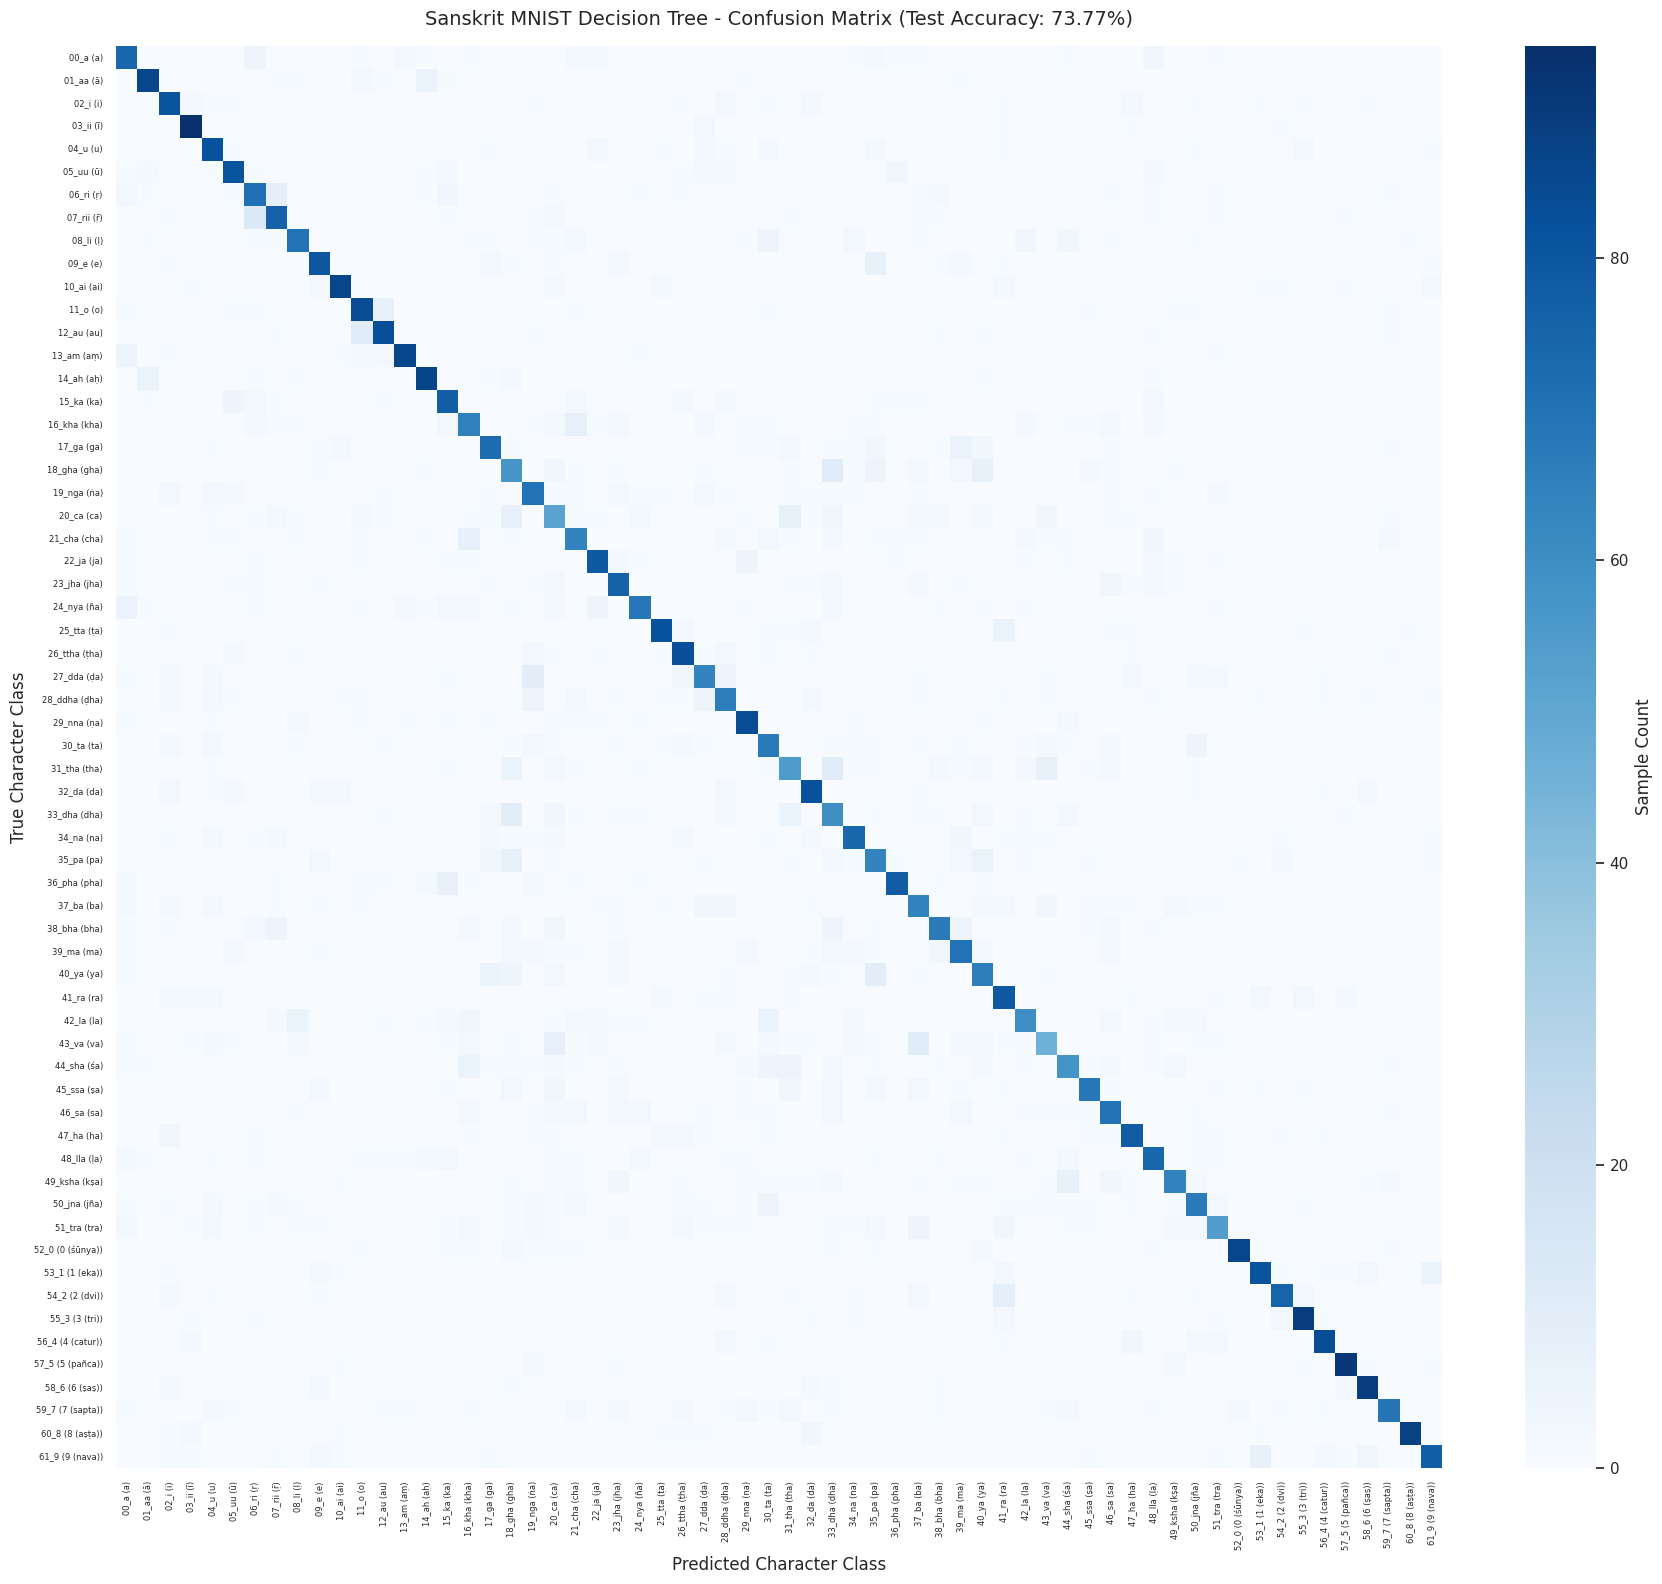

In [11]:
# Compute and visualize Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)

# Top 5 Confused Pairs
cm_off_diag = cm.copy()
np.fill_diagonal(cm_off_diag, 0)
confused_indices = np.unravel_index(np.argsort(cm_off_diag, axis=None)[::-1], cm_off_diag.shape)

print("Top 5 Confused Character Pairs:")
for rank in range(min(5, len(confused_indices[0]))):
    i, j = confused_indices[0][rank], confused_indices[1][rank]
    count = cm_off_diag[i, j]
    if count > 0:
        c_i = SANSKRIT_MAPPING.get(classes[i], {}).get("iast", classes[i])
        c_j = SANSKRIT_MAPPING.get(classes[j], {}).get("iast", classes[j])
        print(f"  {rank+1}. True: '{classes[i]}' ({c_i}) -> Pred: '{classes[j]}' ({c_j}) | Count: {count}")

# Plot Confusion Matrix Heatmap
plt.figure(figsize=(18, 16))
sns.set_theme(style="white")
display_labels = [f"{classes[i]} ({SANSKRIT_MAPPING.get(classes[i], {}).get('iast', '')})" for i in range(len(classes))]

sns.heatmap(
    cm,
    annot=False,
    cmap="Blues",
    xticklabels=display_labels,
    yticklabels=display_labels,
    cbar_kws={"label": "Sample Count"}
)
plt.title(f"Sanskrit MNIST Decision Tree - Confusion Matrix (Test Accuracy: {test_acc*100:.2f}%)", fontsize=14, pad=15)
plt.xlabel("Predicted Character Class", fontsize=12)
plt.ylabel("True Character Class", fontsize=12)
plt.xticks(rotation=90, fontsize=6)
plt.yticks(rotation=0, fontsize=6)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=200)
plt.show()

## 9. Export Trained Model using Joblib
We bundle the trained `DecisionTreeClassifier`, class names, Sanskrit metadata mapping, and feature extraction settings into a single `.joblib` file.
This allows any script to perform inference with zero external dependencies.

In [12]:
# Save model bundle
MODEL_FILE = "sanskrit_dt_model.joblib"

model_bundle = {
    "model": dt_clf,
    "classes": classes,
    "mapping": SANSKRIT_MAPPING,
    "feature_length": X.shape[1],
    "target_size": (28, 28),
    "metrics": {
        "test_accuracy": float(test_acc),
        "macro_precision": float(precision_macro),
        "macro_recall": float(recall_macro),
        "macro_f1": float(f1_macro),
        "weighted_f1": float(f1_weighted)
    },
    "trained_at": time.strftime("%Y-%m-%d %H:%M:%S")
}

joblib.dump(model_bundle, MODEL_FILE)
file_size_mb = os.path.getsize(MODEL_FILE) / (1024 * 1024)
print(f"[+] Successfully exported model bundle to '{MODEL_FILE}' ({file_size_mb:.2f} MB)")

# If running on Google Colab, uncomment to download to your local machine:
# from google.colab import files
# files.download(MODEL_FILE)

[+] Successfully exported model bundle to 'sanskrit_dt_model.joblib' (2.91 MB)


## 10. Test Predictions on New Unseen Images (URL or Local)
Below is the prediction function that classifies unseen Sanskrit characters from either an **online image URL** or a **local image file**.

/tmp/ipykernel_3401/3215001135.py:39: UserWarning: Glyph 2340 (\N{DEVANAGARI LETTER TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3401/3215001135.py:39: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/tmp/ipykernel_3401/3215001135.py:39: UserWarning: Glyph 2415 (\N{DEVANAGARI DIGIT NINE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3401/3215001135.py:39: UserWarning: Glyph 2413 (\N{DEVANAGARI DIGIT SEVEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2340 (\N{DEVANAGARI LETTER TA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Devanagari natively.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/c

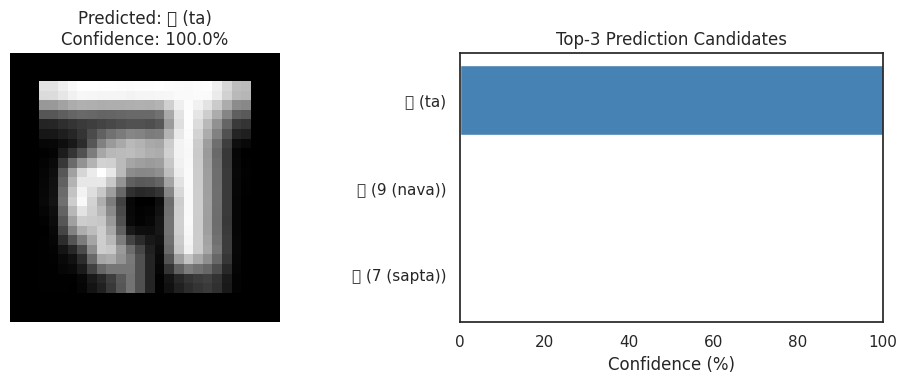

Result: {'class': '30_ta', 'devanagari': 'त', 'iast': 'ta', 'confidence': 1.0}


In [13]:
def predict_sanskrit_character(image_input, model_path="sanskrit_dt_model.joblib", top_k=3):
    """Predicts Sanskrit character from an image URL or local path."""
    bundle = joblib.load(model_path)
    model = bundle["model"]
    classes = bundle["classes"]
    mapping = bundle.get("mapping", SANSKRIT_MAPPING)

    # Preprocess & extract features
    prep_img = preprocess_image(image_input)
    feat = extract_features(image_input).reshape(1, -1)

    probs = model.predict_proba(feat)[0]
    top_indices = np.argsort(probs)[::-1][:top_k]

    best_idx = top_indices[0]
    best_class = classes[best_idx]
    best_meta = mapping.get(best_class, {})

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    # Show preprocessed character
    ax1.imshow(prep_img, cmap="gray")
    ax1.set_title(f"Predicted: {best_meta.get('devanagari', '?')} ({best_meta.get('iast', best_class)})\nConfidence: {probs[best_idx]*100:.1f}%", fontsize=12)
    ax1.axis("off")

    # Top-K candidate probabilities
    cand_labels = [f"{mapping.get(classes[i], {}).get('devanagari', '')} ({mapping.get(classes[i], {}).get('iast', classes[i])})" for i in top_indices]
    cand_probs = [probs[i] * 100 for i in top_indices]

    y_pos = range(len(cand_labels))
    ax2.barh(y_pos, cand_probs, color="steelblue")
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(cand_labels)
    ax2.invert_yaxis()
    ax2.set_xlabel("Confidence (%)")
    ax2.set_xlim(0, 100)
    ax2.set_title(f"Top-{top_k} Prediction Candidates", fontsize=12)

    plt.tight_layout()
    plt.show()

    return {
        "class": best_class,
        "devanagari": best_meta.get("devanagari", "?"),
        "iast": best_meta.get("iast", best_class),
        "confidence": float(probs[best_idx])
    }

# Test with a local sample character:
test_sample = os.path.join(DATA_DIR, "30_ta", "30_0000.png")
result = predict_sanskrit_character(test_sample)
print("Result:", result)

## 11. Standalone CLI Prediction for GitHub Repo Users
To enable viewers of your GitHub repository to test the model in a single command, provide them with `predict.py`.

```bash
# 1. Clone repository
git clone https://github.com/your-username/sanskrit-character-recognition.git
cd sanskrit-character-recognition

# 2. Install requirements
pip install -r requirements.txt

# 3. Classify any character image via URL:
python predict.py --image "https://example.com/sanskrit_char.png"

# Or local image path:
python predict.py images/15_ka/15_0000.png
```